# Exercise 6: Generative modeling with Normalizing Flows

This notebook is a scaffold for the RealNVP experiments in Exercise Sheet 6. Fill in the `TODO` sections, run the experiments, and add short comments where requested.


In [2]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import load_digits, make_moons

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## 1 Two Moons with RealNVP

Implement an affine-coupling RealNVP model for `sklearn.datasets.make_moons(noise=0.1)`. Use two-layer MLPs with ReLU activations for the scale and translation networks. For stability, predict an unconstrained scale `s_tilde` and use `s = tanh(s_tilde)` as the log-scale.


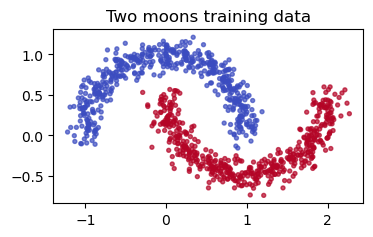

In [3]:
def make_two_moons(n_samples=1000, noise=0.1):
    x, y = make_moons(n_samples=n_samples, shuffle=True, noise=noise, random_state=SEED)
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


def plot_2d(points, title="", ax=None, labels=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    points = points.detach().cpu().numpy() if torch.is_tensor(points) else points
    if labels is not None:
        labels = labels.detach().cpu().numpy() if torch.is_tensor(labels) else labels
    ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.7, c=labels, cmap="coolwarm")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    return ax

x_train, y_train = make_two_moons(n_samples=1000)
plot_2d(x_train, "Two moons training data", labels=y_train)
plt.show()


In [4]:
def subnet_constructor(input_size, hidden_size, output_size):
    """Return the two-hidden-layer MLP used inside each coupling block."""
    # TODO: build Linear -> ReLU -> Linear -> ReLU -> Linear.
    return nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, output_size)
    )


class AffineCouplingLayer(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        assert input_size % 2 == 0, "This exercise assumes an even input dimension."
        self.input_size = input_size
        self.split_size = input_size // 2

        # TODO: create a subnet that maps x1 to both log-scale and translation for x2.
        self.subnet = subnet_constructor(self.split_size, hidden_size, self.split_size * 2)

    def forward(self, x, reverse=False):
        """
        Forward direction: x -> y and return (y, log_det).
        Reverse direction: y -> x and return x.
        """
        # TODO: split x into x1 and x2.
        # TODO: compute s_tilde and t from x1.
        # TODO: set s = tanh(s_tilde).
        # TODO: implement the affine transform and its inverse.
        # TODO: in the forward direction, return the sum of log-scales as log_det.
        # Split x into x1 and x2
        x1, x2 = torch.chunk(x, 2, dim=-1)

        if not reverse:
            # Compute s_tilde and t from x1
            st = self.subnet(x1)
            s_tilde, t = torch.chunk(st, 2, dim=-1)
            
            # Set s = tanh(s_tilde) for stability
            s = torch.tanh(s_tilde)

            # Implement the affine transform
            y1 = x1
            y2 = x2 * torch.exp(s) + t
            y = torch.cat([y1, y2], dim=-1)

            # In the forward direction, return the sum of log-scales as log_det
            log_det = torch.sum(s, dim=-1)
            return y, log_det
        else:
            # In reverse, the input 'x' is conceptually 'y'
            y1, y2 = x1, x2 
            
            st = self.subnet(y1)
            s_tilde, t = torch.chunk(st, 2, dim=-1)
            s = torch.tanh(s_tilde)

            # Implement the inverse transform
            x1_rev = y1
            x2_rev = (y2 - t) * torch.exp(-s)
            x_rev = torch.cat([x1_rev, x2_rev], dim=-1)
            
            return x_rev

class SwapLayer(nn.Module):
    def forward(self, x, reverse=False):
        x1, x2 = torch.chunk(x, 2, dim=-1)
        return torch.cat([x2, x1], dim=-1)


class RealNVP(nn.Module):
    def __init__(self, input_size, hidden_size, n_blocks):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.n_blocks = n_blocks

        # TODO: create n_blocks affine coupling layers.
        # TODO: create swap layers between consecutive coupling layers.
        # Create n_blocks affine coupling layers.
        self.coupling_layers = nn.ModuleList([
            AffineCouplingLayer(input_size, hidden_size) for _ in range(n_blocks)
        ])
        
        # Create swap layers between consecutive coupling layers.
        self.swap_layers = nn.ModuleList([
            SwapLayer() for _ in range(n_blocks)
        ])

    def forward(self, x):
        """Map data x to latent z and return (z, total_log_det)."""
        z = x
        total_log_det = 0
        
        # Apply coupling layers, swaps, and accumulate log-determinants.
        for coupling, swap in zip(self.coupling_layers, self.swap_layers):
            z, log_det = coupling(z)
            total_log_det += log_det
            z = swap(z)
            
        return z, total_log_det

    def inverse(self, z):
        """Map latent z back to data space."""
        x = z
        
        # Undo the forward pass in reverse order.
        for coupling, swap in reversed(list(zip(self.coupling_layers, self.swap_layers))):
            x = swap(x, reverse=True)
            x = coupling(x, reverse=True)
            
        return x

    @torch.no_grad()
    def sample(self, num_samples):
        z = torch.randn(num_samples, self.input_size, device=next(self.parameters()).device)
        return self.inverse(z)


In [5]:
def nll_loss(z, log_det):
    """Negative log-likelihood without the additive Gaussian normalization constant."""
    # TODO: implement mean(0.5 * ||z||^2 - log_det).
    z_sq = torch.sum(z**2, dim=-1)
    return torch.mean(0.5 * z_sq - log_det)


def train_realnvp(model, data_fn, batch_size=1000, epochs=100, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()

    for epoch in range(epochs):
        x, _ = data_fn(batch_size)
        x = x.to(device)

        # TODO: run the model, compute the NLL loss, backpropagate, and step the optimizer.
        optimizer.zero_grad()
        z, log_det = model(x)
        loss = nll_loss(z, log_det)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % max(1, epochs // 5) == 0:
            print(f"Epoch {epoch + 1:4d}/{epochs}: loss = {loss.item():.4f}")

    return model


In [5]:
# Numerical inverse check. This should be close to zero after the TODOs are implemented.
model = RealNVP(input_size=2, hidden_size=16, n_blocks=2).to(device)
x_check, _ = make_two_moons(n_samples=16)
x_check = x_check.to(device)

# TODO: compute z = f(x), x_reconstructed = f^{-1}(z), and print the max reconstruction error.
with torch.no_grad():
    z_check, _ = model(x_check)
    x_reconstructed = model.inverse(z_check)
    
max_error = torch.max(torch.abs(x_check - x_reconstructed)).item()
print(f"max Reconstruction Error: {max_error:.6f}")

max Reconstruction Error: 0.000000



Training RealNVP (hidden=16, blocks=2)...
Epoch   20/100: loss = 0.6066
Epoch   40/100: loss = 0.3745
Epoch   60/100: loss = 0.1415
Epoch   80/100: loss = 0.0131
Epoch  100/100: loss = -0.0380

Training RealNVP (hidden=64, blocks=2)...


/tmp/ipykernel_4468/828721915.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.7, c=labels, cmap="coolwarm")


Epoch   20/100: loss = 0.0348
Epoch   40/100: loss = -0.0750
Epoch   60/100: loss = -0.1315
Epoch   80/100: loss = -0.1569
Epoch  100/100: loss = -0.1716

Training RealNVP (hidden=128, blocks=2)...
Epoch   20/100: loss = -0.0790
Epoch   40/100: loss = -0.1552
Epoch   60/100: loss = -0.1968
Epoch   80/100: loss = -0.2500
Epoch  100/100: loss = -0.3279

Training RealNVP (hidden=16, blocks=5)...
Epoch   20/100: loss = 0.3807
Epoch   40/100: loss = 0.0727
Epoch   60/100: loss = -0.0082
Epoch   80/100: loss = -0.0448
Epoch  100/100: loss = -0.0765

Training RealNVP (hidden=64, blocks=5)...
Epoch   20/100: loss = -0.1074
Epoch   40/100: loss = -0.2018
Epoch   60/100: loss = -0.3203
Epoch   80/100: loss = -0.5093
Epoch  100/100: loss = -0.6309

Training RealNVP (hidden=128, blocks=5)...
Epoch   20/100: loss = -0.1468
Epoch   40/100: loss = -0.2961
Epoch   60/100: loss = -0.4976
Epoch   80/100: loss = -0.6111
Epoch  100/100: loss = -0.6652

Training RealNVP (hidden=16, blocks=10)...
Epoch   20

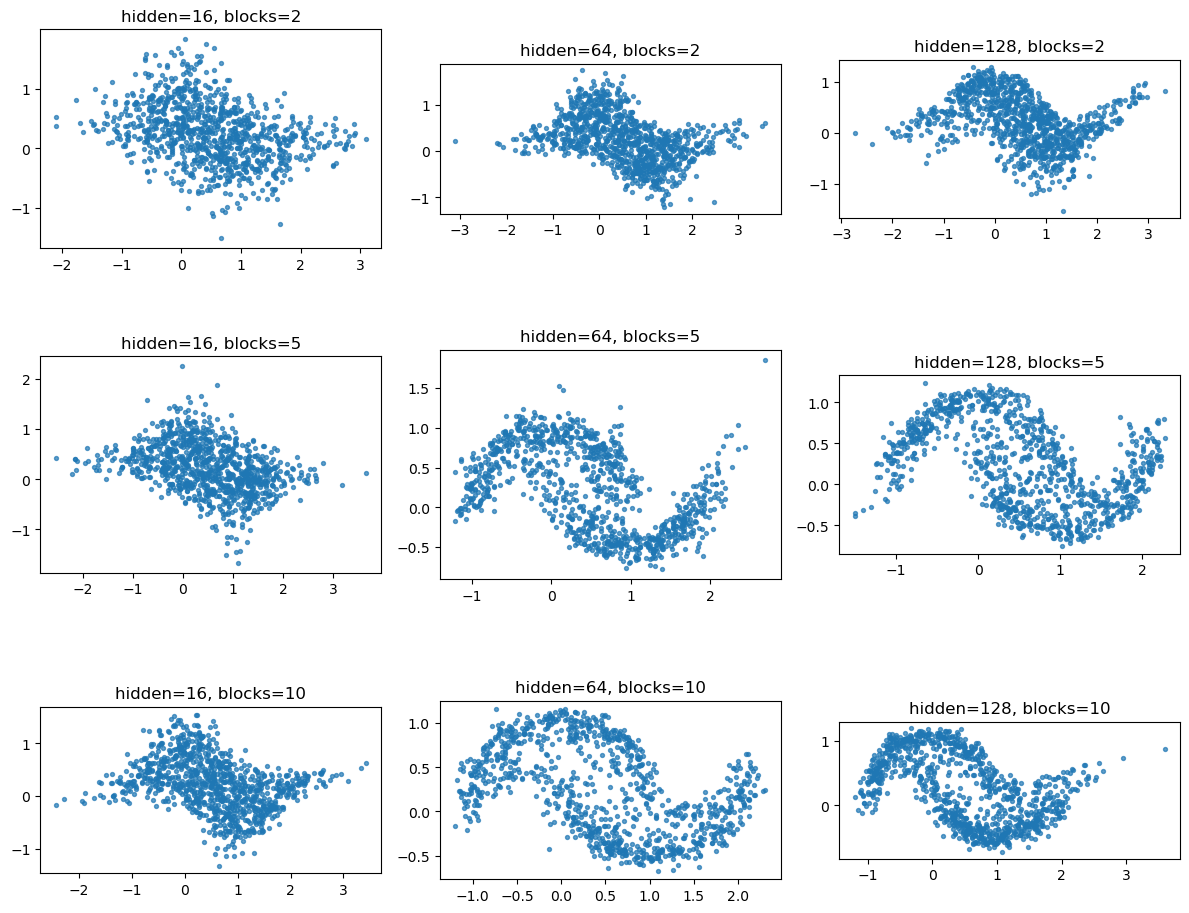

In [7]:
# Task 1 experiment grid: hidden dimensions [16, 64, 128] and coupling blocks [2, 5, 10].
hidden_sizes = [16, 64, 128]
n_blocks_list = [2, 5, 10]

fig, axes = plt.subplots(len(n_blocks_list), len(hidden_sizes), figsize=(12, 10))

#save the largest model for inspection
best_model = None

for row, n_blocks in enumerate(n_blocks_list):
    for col, hidden_size in enumerate(hidden_sizes):
        # TODO: train a RealNVP(input_size=2, hidden_size=hidden_size, n_blocks=n_blocks) for 100 epochs.
        # TODO: plot generated samples in axes[row, col].
        print(f"\nTraining RealNVP (hidden={hidden_size}, blocks={n_blocks})...")
        
        # Instantiate and train the model
        model = RealNVP(input_size=2, hidden_size=hidden_size, n_blocks=n_blocks).to(device)
        model = train_realnvp(model, make_two_moons, batch_size=1000, epochs=100, lr=1e-3)
        
        # Save the 128-hidden, 10-block model as best_model
        if hidden_size == 128 and n_blocks == 10:
            best_model = model
            
        # Generate samples and plot them in the grid
        samples = model.sample(1000)
        plot_2d(samples, ax=axes[row, col])
        axes[row, col].set_title(f"hidden={hidden_size}, blocks={n_blocks}")

plt.tight_layout()
plt.show()


/tmp/ipykernel_4468/828721915.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.7, c=labels, cmap="coolwarm")


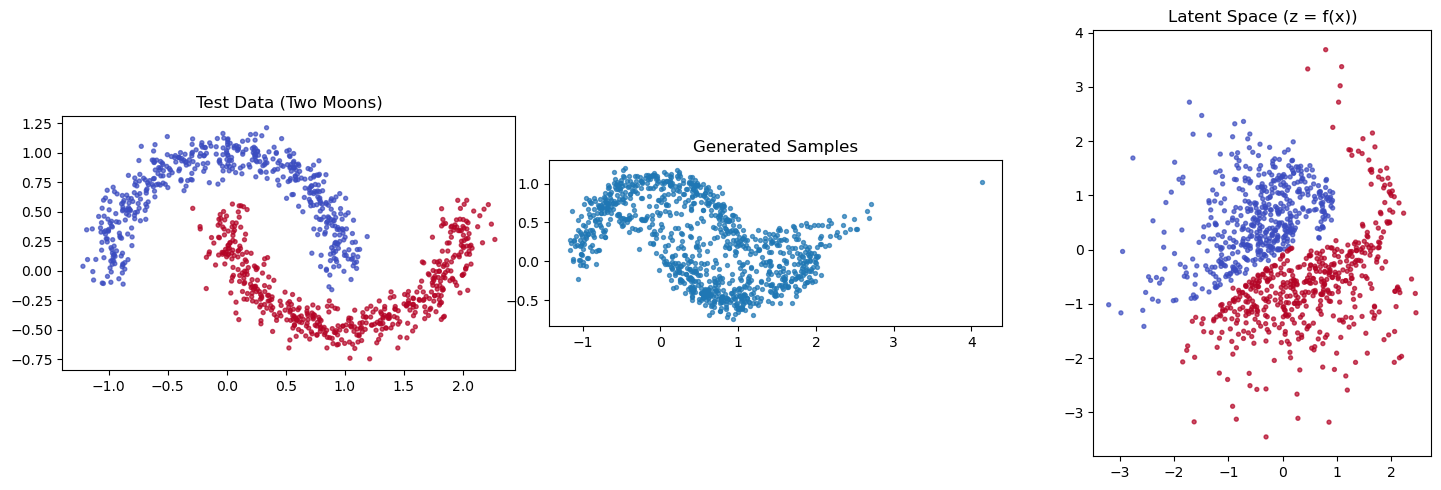

In [11]:
# Latent-space inspection for your best two-moons model.
# TODO: choose a trained model from the grid above or retrain your best configuration.
# TODO: plot training/test data, generated samples, and latent codes z = f(x).
# Latent-space inspection for the best two-moons model
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Plot test data on the first subplot (axes[0])
x_test, y_test = make_two_moons(n_samples=1000)
x_test = x_test.to(device)
plot_2d(x_test, title="Test Data (Two Moons)", ax=axes[0], labels=y_test)

# 2. Plot generated samples on the second subplot (axes[1])
generated_samples = best_model.sample(1000)
plot_2d(generated_samples, title="Generated Samples", ax=axes[1])

# 3. Plot latent codes z = f(x) on the third subplot (axes[2])
with torch.no_grad():
    z, _ = best_model(x_test)
plot_2d(z, title="Latent Space (z = f(x))", ax=axes[2], labels=y_test)

plt.tight_layout()
plt.show()

### Task 1 comments

Write a short comment on the generated sample quality and whether the latent codes look approximately normally distributed.

Sample Quality:
Models with fewer blocks or small hidden size fail to form the moon shape. Generally speaking the hidden dimension has a greater influence on quality, because all samples with a hidden dimesnion of 128 show at least the beginnings of a moon shape. The number of blocks also determines the quality but it cant outhweigh the hidden dimension because even with 10 blocks and a hidden dimension of 16 the moon shape is still not recognisable.

Latent Space:
The latend codes (z=f(x)) seem to be approximately normally distribnuted and the vast majority of data points is within [-3,3]. However the two classes are still linearly seperable wihtin the gaussian cloud.


## 2 Digits with RealNVP

Repeat the experiment on `sklearn.datasets.load_digits()`. Flatten each `8 x 8` image to a vector in `R^64`. Use hidden dimension 128, 8 coupling blocks, and train for 2000 epochs. Compare a model trained on all digits with a model overfitted to a single digit, for example digit `5`.


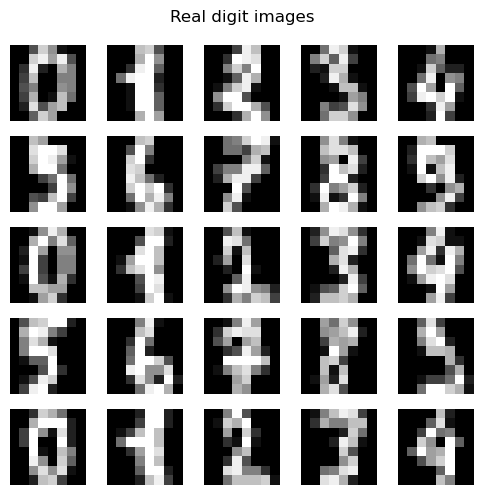

In [6]:
def load_digits_tensor(digit=None):
    digits = load_digits()
    x = digits.data.astype("float32") / 16.0
    y = digits.target.astype("int64")
    if digit is not None:
        mask = y == digit
        x, y = x[mask], y[mask]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


def plot_digit_grid(images, title="", n=25):
    images = images.detach().cpu() if torch.is_tensor(images) else torch.tensor(images)
    n = min(n, images.shape[0])
    side = int(math.ceil(math.sqrt(n)))
    fig, axes = plt.subplots(side, side, figsize=(side, side))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for i in range(n):
        axes[i].imshow(images[i].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    fig.suptitle(title)
    plt.tight_layout()
    return fig

x_digits, y_digits = load_digits_tensor()
plot_digit_grid(x_digits, "Real digit images")
plt.show()


In [ ]:
def make_digits_batch(batch_size, digit=None):
    x, y = load_digits_tensor(digit=digit)
    idx = torch.randint(0, x.shape[0], (batch_size,))
    return x[idx], y[idx]

# TODO: train a RealNVP(input_size=64, hidden_size=128, n_blocks=8) on all digits for 2000 epochs.
# TODO: generate samples and display them with plot_digit_grid.
print("Training RealNVP on all digits...")
model_all_digits = RealNVP(input_size=64, hidden_size=128, n_blocks=8).to(device)
model_all_digits = train_realnvp(
    model_all_digits,
    lambda n: make_digits_batch(n, digit=None),
    batch_size=256,
    epochs=2000,
    lr=1e-3,
)

samples_all = model_all_digits.sample(25).clamp(0, 1)
plot_digit_grid(samples_all, title="Generated Digits (all-digits model)")
plt.show()

Training RealNVP on digit 5 only...
Epoch  400/2000: loss = -178.7034
Epoch  800/2000: loss = -198.5701
Epoch 1200/2000: loss = -208.7603
Epoch 1600/2000: loss = -214.6177
Epoch 2000/2000: loss = -213.6629


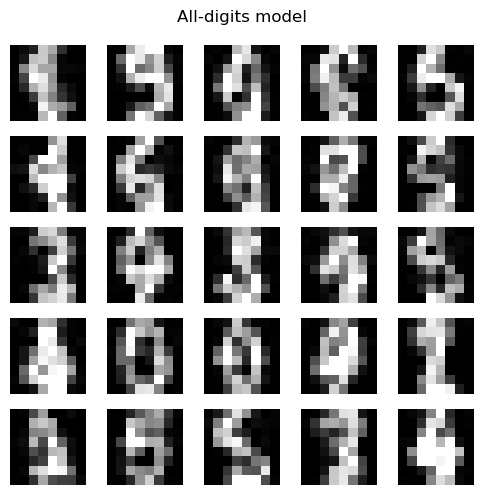

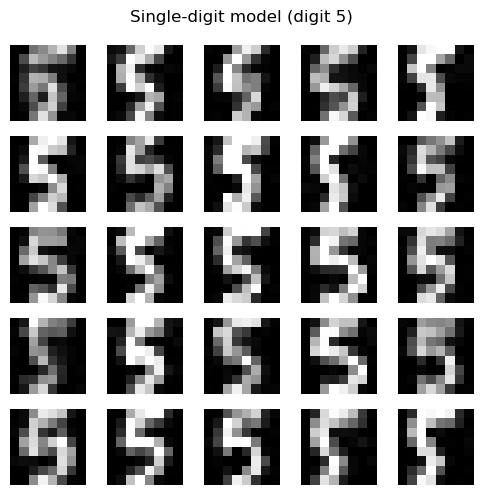

In [10]:
# TODO: train another RealNVP on only one digit, for example digit=5.
# TODO: compare generated images from the all-digits model and the single-digit model.
print("Training RealNVP on digit 5 only...")
model_digit5 = RealNVP(input_size=64, hidden_size=128, n_blocks=8).to(device)
model_digit5 = train_realnvp(
    model_digit5,
    lambda n: make_digits_batch(n, digit=5),
    batch_size=64,
    epochs=2000,
    lr=1e-3,
)

samples_digit5 = model_digit5.sample(25).clamp(0, 1)

plot_digit_grid(samples_all, title="All-digits model", n=25)
plt.show()
plot_digit_grid(samples_digit5, title="Single-digit model (digit 5)", n=25)
plt.show()

### Task 2 comments

Write a short comparison of the generated digits from the all-digits model and the single-digit model.

The all-digits model has a much harder job because it is trained on all 0-9 digets. Therefore the generated digits are mostly recognisable but quite blurry. The single-digit model is only trained on variations of the same digit and thus its generative results are clearer and less blurry.

## 3 Conditional RealNVP on digits

Extend the RealNVP implementation to model `p(x | y)` using a one-hot digit label as an additional input to the coupling networks. Train with hidden dimension 512 and generate samples for fixed labels `0, ..., 9`.


In [11]:
class ConditionalAffineCouplingLayer(nn.Module):
    def __init__(self, input_size, hidden_size, condition_size):
        super().__init__()
        assert input_size % 2 == 0, "This exercise assumes an even input dimension."
        self.input_size = input_size
        self.split_size = input_size // 2
        self.condition_size = condition_size

        # TODO: create a subnet that receives concat(x1, one_hot_label).
        self.subnet = subnet_constructor(self.split_size + condition_size, hidden_size, self.split_size * 2)

    def forward(self, x, condition, reverse=False):
        # TODO: implement the conditional affine coupling transform.
        x1, x2 = torch.chunk(x, 2, dim=-1)
        # Concatenate x1 with the one-hot label before passing to subnet
        x1_cond = torch.cat([x1, condition], dim=-1)
        st = self.subnet(x1_cond)
        s_tilde, t = torch.chunk(st, 2, dim=-1)
        s = torch.tanh(s_tilde)

        if not reverse:
            y1 = x1
            y2 = x2 * torch.exp(s) + t
            log_det = torch.sum(s, dim=-1)
            return torch.cat([y1, y2], dim=-1), log_det
        else:
            x1_rev = x1
            x2_rev = (x2 - t) * torch.exp(-s)
            return torch.cat([x1_rev, x2_rev], dim=-1)


class ConditionalRealNVP(nn.Module):
    def __init__(self, input_size, hidden_size, n_blocks, condition_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.n_blocks = n_blocks
        self.condition_size = condition_size

        # TODO: create conditional coupling layers and swaps.
        self.coupling_layers = nn.ModuleList([
            ConditionalAffineCouplingLayer(input_size, hidden_size, condition_size)
            for _ in range(n_blocks)
        ])
        self.swap_layers = nn.ModuleList([
            SwapLayer() for _ in range(n_blocks)
        ])

    def forward(self, x, labels):
        # TODO: one-hot encode labels and compute z plus total log-det.
        condition = F.one_hot(labels, num_classes=self.condition_size).float()
        z = x
        total_log_det = 0
        for coupling, swap in zip(self.coupling_layers, self.swap_layers):
            z, log_det = coupling(z, condition)
            total_log_det += log_det
            z = swap(z)
        return z, total_log_det

    def inverse(self, z, labels):
        # TODO: invert the conditional flow using the same labels.
        condition = F.one_hot(labels, num_classes=self.condition_size).float()
        x = z
        for coupling, swap in reversed(list(zip(self.coupling_layers, self.swap_layers))):
            x = swap(x, reverse=True)
            x = coupling(x, condition, reverse=True)
        return x

    @torch.no_grad()
    def sample(self, labels):
        labels = torch.as_tensor(labels, dtype=torch.long, device=next(self.parameters()).device)
        z = torch.randn(labels.shape[0], self.input_size, device=labels.device)
        return self.inverse(z, labels)

In [12]:
def train_conditional_realnvp(model, batch_size=256, epochs=2000, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()

    for epoch in range(epochs):
        x, labels = make_digits_batch(batch_size)
        x, labels = x.to(device), labels.to(device)

        # TODO: run the conditional model, compute the NLL loss, backpropagate, and step the optimizer.
        optimizer.zero_grad()
        z, log_det = model(x, labels)
        loss = nll_loss(z, log_det)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % max(1, epochs // 5) == 0:
            print(f"Epoch {epoch + 1:4d}/{epochs}: loss = {loss.item():.4f}")

    return model

Training ConditionalRealNVP on all digits...
Epoch  400/2000: loss = -160.3745
Epoch  800/2000: loss = -181.9620
Epoch 1200/2000: loss = -198.2715
Epoch 1600/2000: loss = -198.0304
Epoch 2000/2000: loss = -213.2971


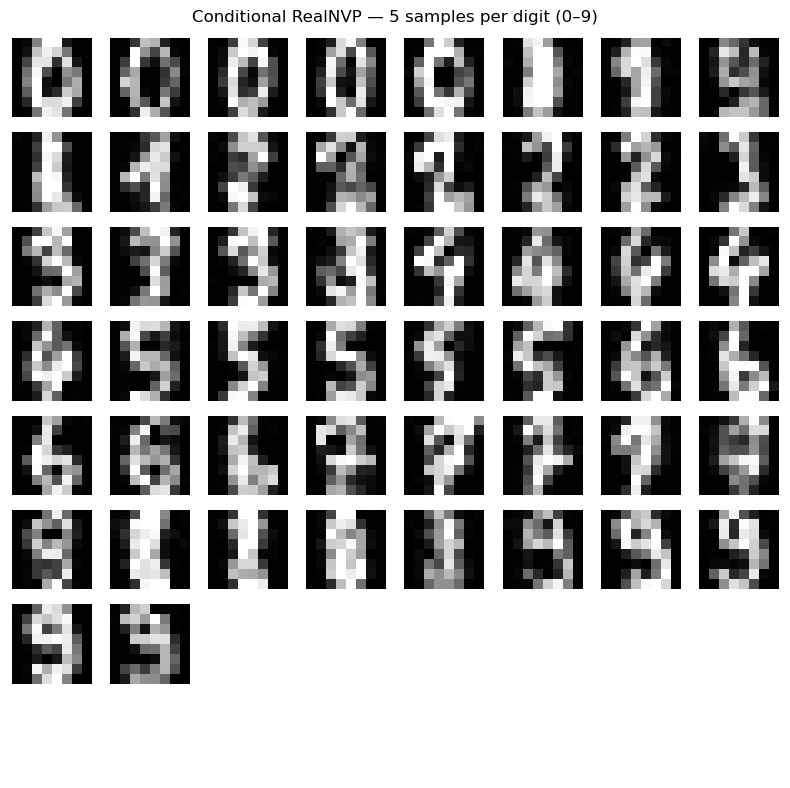

In [13]:
# TODO: train ConditionalRealNVP(input_size=64, hidden_size=512, n_blocks=8, condition_size=10).
# TODO: generate several samples for each fixed label 0, ..., 9 and show them in a grid.
print("Training ConditionalRealNVP on all digits...")
model_conditional = ConditionalRealNVP(input_size=64, hidden_size=512, n_blocks=8, condition_size=10).to(device)
model_conditional = train_conditional_realnvp(model_conditional, batch_size=256, epochs=2000, lr=1e-3)

# Generate 5 samples for each digit 0..9 (50 images total)
n_per_digit = 5
labels = torch.arange(10).repeat_interleave(n_per_digit)  # [0,0,0,0,0, 1,1,1,1,1, ...]
samples_cond = model_conditional.sample(labels).clamp(0, 1)
plot_digit_grid(samples_cond, title="Conditional RealNVP — 5 samples per digit (0–9)", n=50)
plt.show()

### Task 3 comments

Write a short comment on whether generated samples match the requested digit labels, and compare the conditional model to the unconditional model from Task 2.

As requested the conditional model generates vive samples or each digit from 0-9. The sample quality is similar to the unconditional all-digit model. However, the  conditional model allows us to control what digits are generated while the unconditional version can only generate random digits.
